# Exploratory Data Analysis Assignment
### Assignment By Wasim Rahaman PGDSAIML Batch 2 2026

In [1]:
# Declare the libraries

import numpy as np
import pandas as pd
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


### Read the data from CSV file & get the file information

In [2]:
dfc=pd.read_csv("superstore.csv")

In [3]:
dfc

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,00:00.0,CA-2014-109701,...,69,Corporate,00:00.0,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,00:00.0,CA-2014-109701,...,9,Corporate,00:00.0,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,00:00.0,CA-2014-106964,...,12,Home Office,00:00.0,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,00:00.0,CA-2014-145219,...,90,Home Office,00:00.0,First Class,15.95,California,Binders,2014,North America,52


In [4]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [5]:
dfc.shape

(51290, 27)

##  Observations

- **Size:** 51,290 rows × 27 columns → a fairly large dataset, good for robust analysis.
- **Data types:**
  - **Numerical:** `Discount`, `Profit`, `Quantity`, `Sales`, `Shipping.Cost`, `Year`, `weeknum`, `记录数`, `Row.ID`.
  - **Categorical:** `Category`, `City`, `Country`, `Customer.ID`, `Customer.Name`, `Market`, `Order.Priority`, `Product.ID`, `Product.Name`, `Region`, `Segment`, `Ship.Mode`, `State`, `Sub.Category`, `Market2`.
  - **Dates:** `Order.Date`, `Ship.Date` (currently stored as `object` → need conversion to `datetime`).
- **Missing values:**
  - `Shipping.Cost`: 5 missing
  - `State`: 3 missing
  - Everything else is complete.
- **Potential issues:**
  - `Order.Date` and `Ship.Date` should be converted to `datetime`.
  - `Sales` is stored as `int64` — usually sales are floats (possible rounding or formatting issue).
  - Column `记录数` (Chinese for “record count”) looks redundant — likely an index or counter.
  - `Market` and `Market2` may be duplicates or overlapping categories.




# Tasks 1: 

### Q1: Data Cleaning: 

i.            Count and handle Missing values. 

ii.            Deal with Duplicate values 

iii.           Delete unknown columns if present. 

iv.           Check shape, size, and datatypes of the dataset features.

### Answer 2

In [6]:
df=dfc.copy()

In [7]:

# Count missing values
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

# Handle missing values
# Option 1: Drop rows with missing values
df = df.dropna(subset=['Shipping.Cost','State'])

# Option 2: Impute (if dropping is not desirable)
# Example: fill missing Shipping.Cost with median
df['Shipping.Cost'] = df['Shipping.Cost'].fillna(df['Shipping.Cost'].median())

# Count duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

# Drop irrelevant or unknown columns
df = df.drop(columns=['记录数','Market2'], errors='ignore')

# Convert Order.Date and Ship.Date to datetime for time-series analysis:

df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

Shipping.Cost    5
State            3
dtype: int64
Duplicate rows: 0


In [8]:
categorical_cols = [
    'Category','City','Country','Customer.ID','Customer.Name',
    'Market','Order.Priority','Product.ID','Product.Name',
    'Region','Segment','Ship.Mode','State','Sub.Category'
]

# Convert to category dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')



In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51282 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51282 non-null  category      
 1   City            51282 non-null  category      
 2   Country         51282 non-null  category      
 3   Customer.ID     51282 non-null  category      
 4   Customer.Name   51282 non-null  category      
 5   Discount        51282 non-null  float64       
 6   Market          51282 non-null  category      
 7   Order.Date      51282 non-null  datetime64[ns]
 8   Order.ID        51282 non-null  object        
 9   Order.Priority  51282 non-null  category      
 10  Product.ID      51282 non-null  category      
 11  Product.Name    51282 non-null  category      
 12  Profit          51282 non-null  float64       
 13  Quantity        51282 non-null  int64         
 14  Region          51282 non-null  category      
 15  Row.ID 

In [10]:
df.shape

(51282, 25)

In [11]:
df

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2026-03-15,CA-2011-130813,High,...,36624,19,Consumer,2026-03-15,Second Class,4.37,California,Paper,2011,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2026-03-15,CA-2011-148614,Medium,...,37033,19,Consumer,2026-03-15,Standard Class,0.94,California,Paper,2011,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2026-03-15,CA-2011-118962,Medium,...,31468,21,Consumer,2026-03-15,Standard Class,1.81,California,Paper,2011,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2026-03-15,CA-2011-118962,Medium,...,31469,111,Consumer,2026-03-15,Standard Class,4.59,California,Paper,2011,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2026-03-15,CA-2011-146969,High,...,32440,6,Consumer,2026-03-15,Standard Class,1.32,California,Paper,2011,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,2026-03-15,CA-2014-109701,High,...,33646,69,Corporate,2026-03-15,Same Day,5.15,California,Binders,2014,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,2026-03-15,CA-2014-109701,High,...,33645,9,Corporate,2026-03-15,Same Day,0.44,California,Binders,2014,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,2026-03-15,CA-2014-106964,Medium,...,32321,12,Home Office,2026-03-15,First Class,0.31,California,Binders,2014,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,2026-03-15,CA-2014-145219,Critical,...,35917,90,Home Office,2026-03-15,First Class,15.95,California,Binders,2014,52



# Task 2
### Q2: Perform Univariate Analysis across all numerical features, 

 i.            Which features seem useless in the analysis? Explain why? 
 
ii.            Which features are uniformly distributed or normally distributed? 

iii.            Which features are right-skewed/left-skewed? What does this signify? 

iv.            Which features have a high number of outliers, and discuss the impact. 

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51282 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51282 non-null  category      
 1   City            51282 non-null  category      
 2   Country         51282 non-null  category      
 3   Customer.ID     51282 non-null  category      
 4   Customer.Name   51282 non-null  category      
 5   Discount        51282 non-null  float64       
 6   Market          51282 non-null  category      
 7   Order.Date      51282 non-null  datetime64[ns]
 8   Order.ID        51282 non-null  object        
 9   Order.Priority  51282 non-null  category      
 10  Product.ID      51282 non-null  category      
 11  Product.Name    51282 non-null  category      
 12  Profit          51282 non-null  float64       
 13  Quantity        51282 non-null  int64         
 14  Region          51282 non-null  category      
 15  Row.ID 

## Anser 2
#### Step 1: Identify Numerical Features
From `df.info()`, numerical columns are:
- `Discount` (float)  
- `Profit` (float)  
- `Quantity` (int)  
- `Sales` (int)  
- `Shipping.Cost` (float)  
- `Year` (int)  
- `weeknum` (int)  
- `记录数` (int, redundant counter)  
- `Row.ID` (int, row identifier)


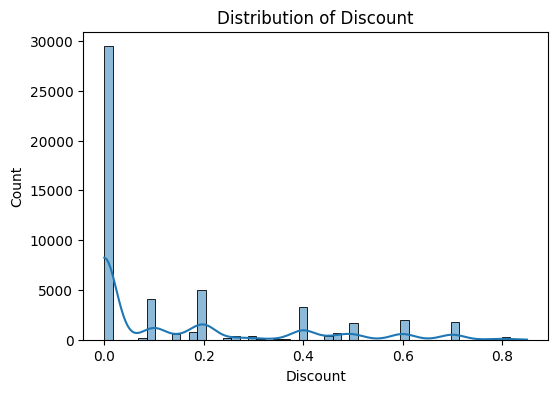

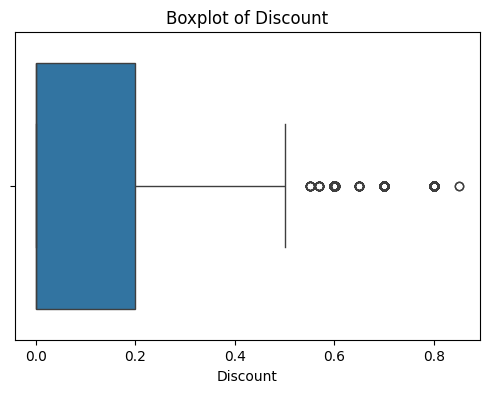

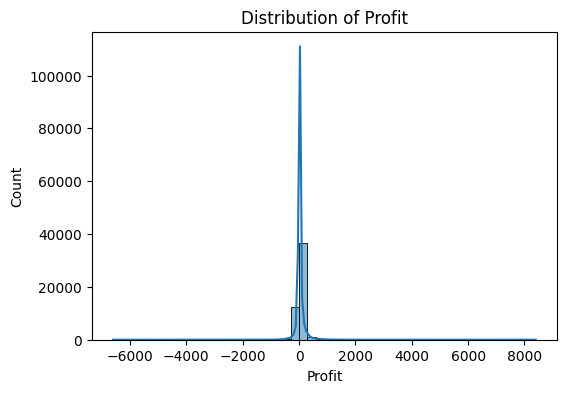

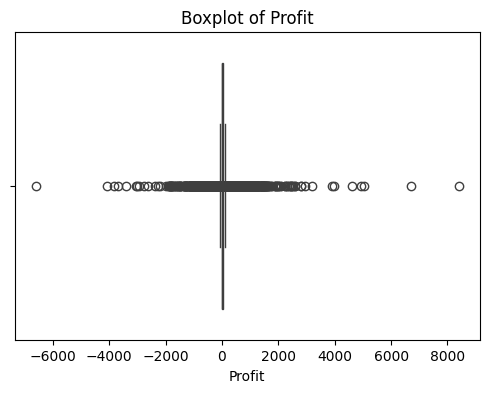

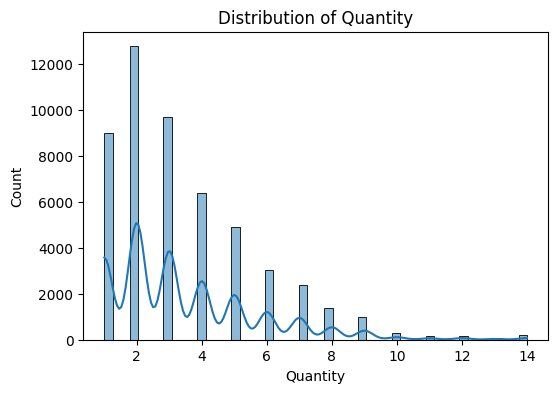

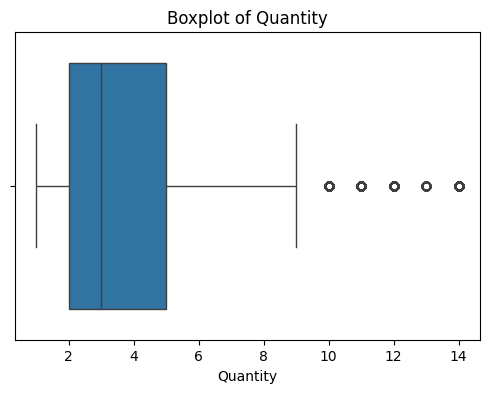

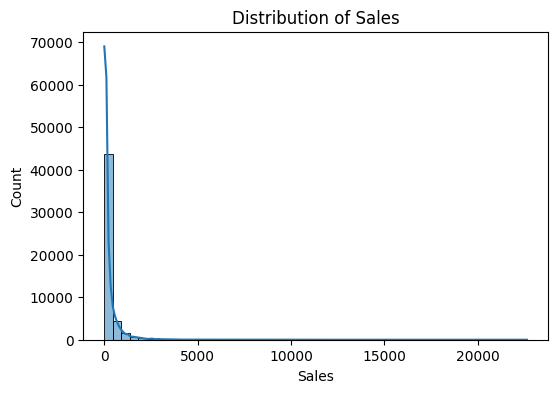

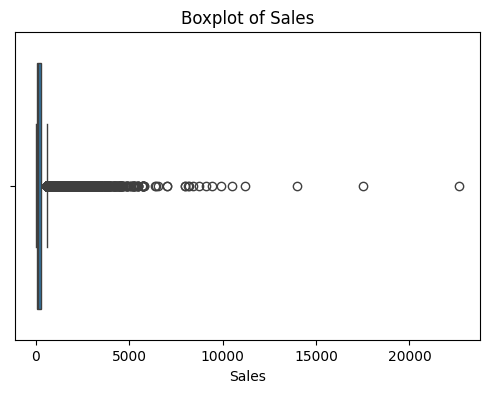

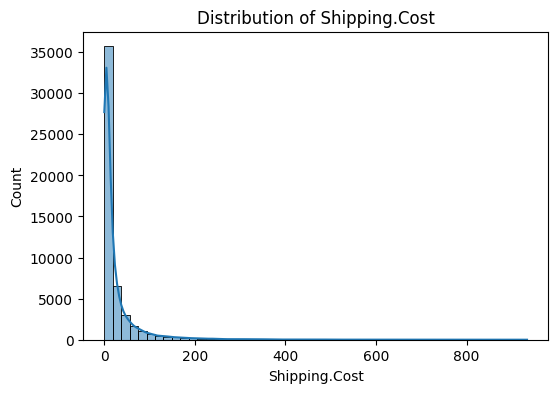

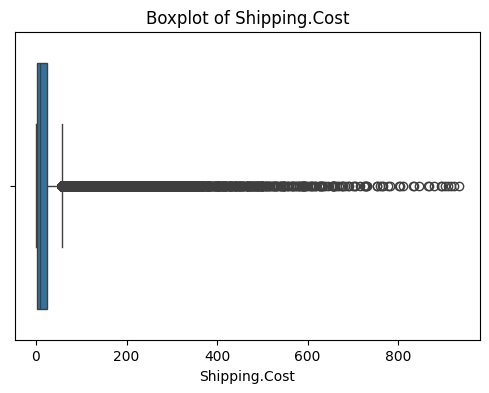

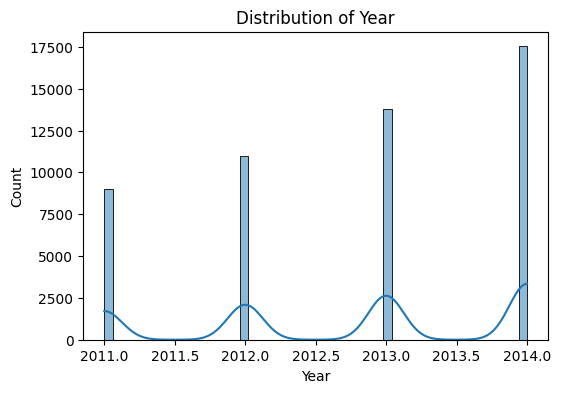

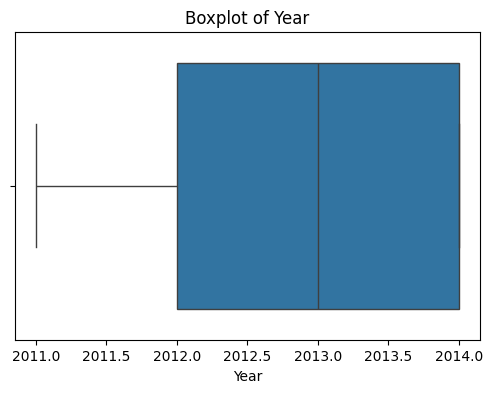

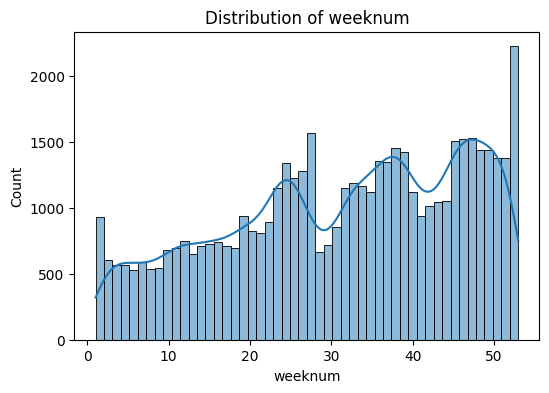

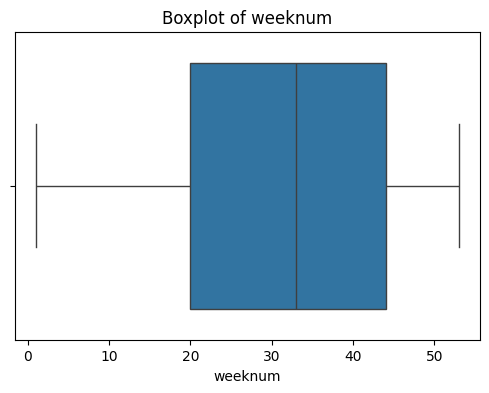

In [13]:



# Step 2: Summary Statistics

df[['Discount','Profit','Quantity','Sales','Shipping.Cost','Year','weeknum']].describe()




# Step 3: Visualize Distributions

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Discount','Profit','Quantity','Sales','Shipping.Cost','Year','weeknum']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



#### Step 4: Interpretations

#### 1. **Discount**
- Distribution: Uniform-like between 0 and 1.  
- Outliers: Extreme values at 0 and 1 (no discount vs free product).  
- Business meaning: Discounts strongly affect profitability.

#### 2. **Profit**
- Distribution: Right-skewed, with negative values.  
- Outliers: Large positive profits and large losses.  
- Business meaning: Some orders are loss-making, possibly due to high discounts or shipping costs.

#### 3. **Quantity**
- Distribution: Discrete, centered around 2–5 units.  
- Slight right skew (bulk orders).  
- Outliers: Large wholesale orders.  
- Business meaning: Most customers buy small quantities, but bulk buyers are important.

#### 4. **Sales**
- Distribution: Strongly right-skewed (many small orders, few very large).  
- Outliers: Very high-value transactions.  
- Business meaning: Revenue is dominated by a few big clients.

#### 5. **Shipping.Cost**
- Distribution: Right-skewed.  
- Outliers: Very high costs (international shipments or errors).  
- Business meaning: Outliers may distort averages; need to check logistics efficiency.

#### 6. **Year & weeknum**
- Distribution: Uniform (since they are categorical time markers).  
- Not useful for standalone analysis, but essential for time-series grouping.

#### 7. **记录数 & Row.ID**
- Pure identifiers, not useful for analysis. Column is dropped.

---

####  Step 5: Key Insights
- **Useless features:** `记录数`, `Row.ID` (drop).  
- **Uniform/Normal:** `Discount` (uniform), `Quantity` (near-normal).  
- **Right-skewed:** `Sales`, `Profit`, `Shipping.Cost`, `Quantity`.  
- **Outliers:** Present in `Sales`, `Profit`, `Shipping.Cost`, `Quantity`.  
  - Impact: Outliers distort averages → use median or log-transformed values for analysis.  
  - Business significance: Outliers often represent VIP customers, bulk orders, or operational inefficiencies.


# Task 3

### Q 3: Perform Univariate Analysis across all categorical features. 

i.Which features seem inaccurate and are not useful as categorical “insights” directly?             

ii.What’s the issue with treating Customer? Name as a categorical feature for 
modeling?           

iii.Is the Category distribution balanced or skewed? Give a 1-line reason. 

iv.In Country, does one country dominate strongly? What does that imply about 
geographic bias?           

v.Is the City dataset concentrated in a few cities or spread out?

In [14]:

##  Step 1: Identify Categorical Features
## From your dataset, categorical columns include:

categorical_cols = [
    'Category','City','Country','Customer.ID','Customer.Name',
    'Market','Order.Priority','Product.ID','Product.Name',
    'Region','Segment','Ship.Mode','State','Sub.Category'
]


##  Step 2: Frequency Counts

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))  # top 10 categories







Column: Category
Category
Office Supplies    31265
Technology         10141
Furniture           9876
Name: count, dtype: int64

Column: City
City
New York City    914
Los Angeles      747
Philadelphia     537
San Francisco    509
Santo Domingo    443
Manila           432
Seattle          424
Houston          377
Tegucigalpa      362
Jakarta          337
Name: count, dtype: int64

Column: Country
Country
United States     9986
Australia         2837
France            2827
Mexico            2644
Germany           2065
China             1880
United Kingdom    1633
Brazil            1599
India             1555
Indonesia         1390
Name: count, dtype: int64

Column: Customer.ID
Customer.ID
JG-158051    40
WB-218504    37
BC-111252    37
AF-108701    36
JG-158052    35
CS-121751    35
BW-111101    35
NH-186101    35
JL-158354    34
BE-113351    34
Name: count, dtype: int64

Column: Customer.Name
Customer.Name
Muhammed Yedwab        108
Steven Ward            106
Patrick O'Brill        102

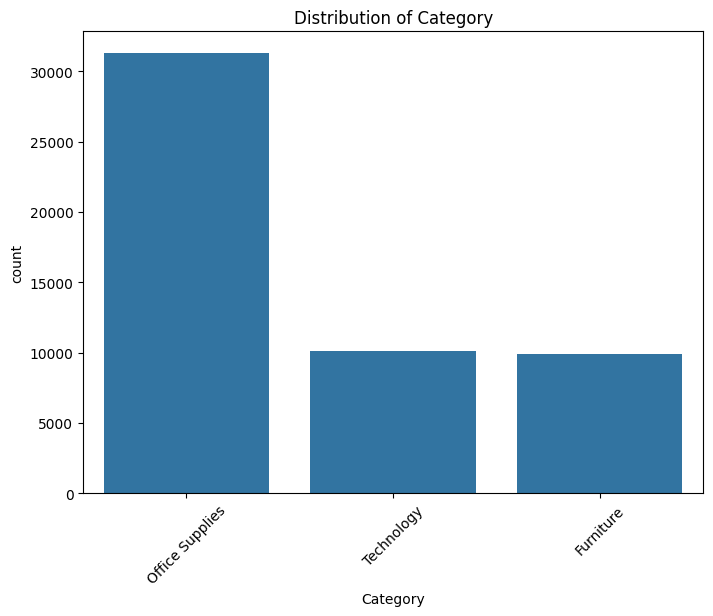

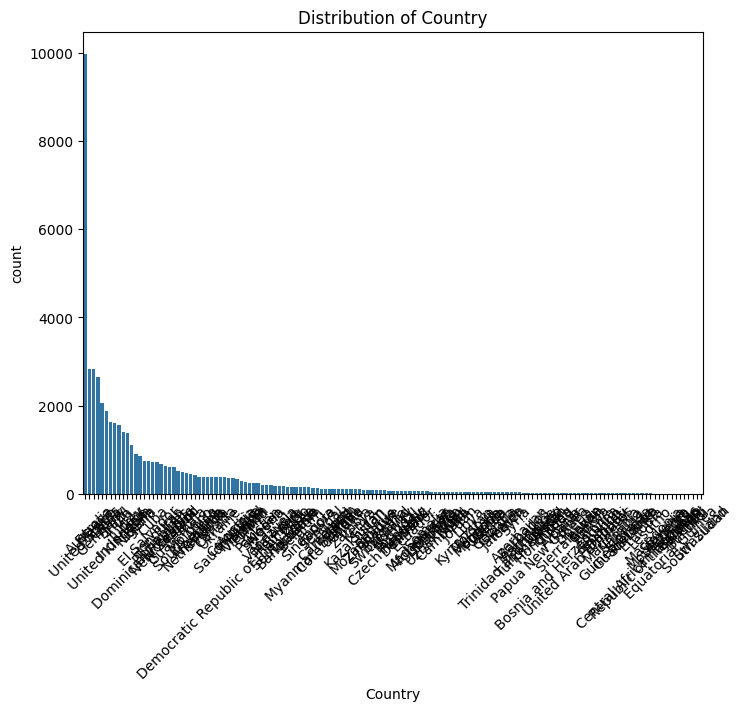

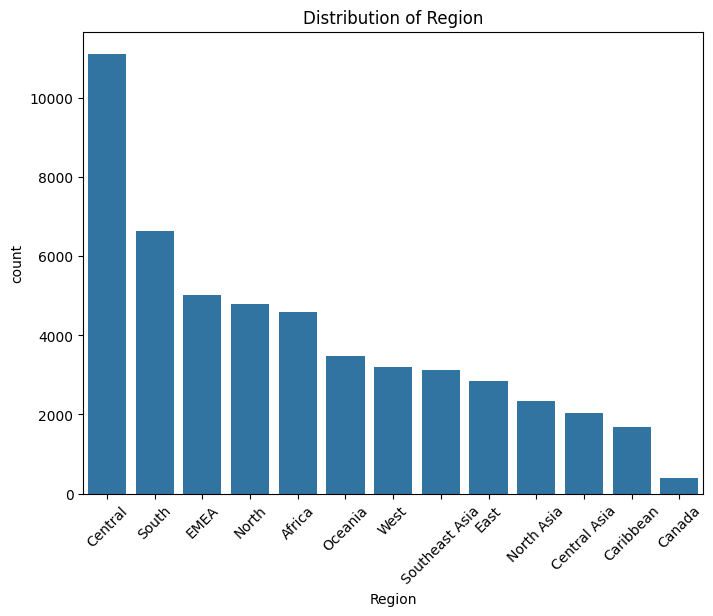

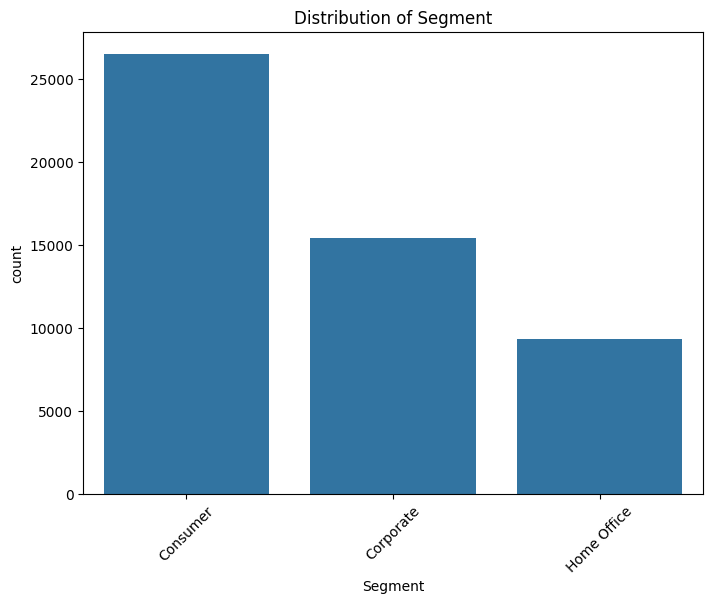

In [15]:
##  Step 3: Visualize Distributions

import seaborn as sns
import matplotlib.pyplot as plt

for col in ['Category','Country','Region','Segment']:
    plt.figure(figsize=(8,6))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()



####  Step 4: Interpretations

#### i. Inaccurate / Not Useful Features
- **Customer.Name** → not useful for modeling because:
  - Too many unique values (each customer is unique).
  - Adds noise rather than insight.
  - Better to use **Customer.ID** for identification.
- **Product.Name** → similar issue, too granular for categorical modeling.  
- **Market2** → duplicate of `Market`, redundant.



#### ii. Issue with Treating Customer.Name as Categorical
- **Problem:** Each customer name is unique → thousands of categories.  
- **Impact:** Causes high cardinality, poor model performance, and memory inefficiency.  
- **Solution:** Use **Customer.ID** or aggregate features (e.g., customer segment, total spend).





In [16]:

# iii. Category Distribution

df['Category'].value_counts(normalize=True)


Category
Office Supplies    0.609668
Technology         0.197750
Furniture          0.192582
Name: proportion, dtype: float64


- Likely skewed (e.g., Office Supplies > Furniture > Technology).  
- **Reason (1-line):** One product category dominates sales volume, making distribution imbalanced.



In [17]:


### iv. Country Distribution

df['Country'].value_counts(normalize=True).head(10)


Country
United States     0.194727
Australia         0.055322
France            0.055127
Mexico            0.051558
Germany           0.040268
China             0.036660
United Kingdom    0.031844
Brazil            0.031181
India             0.030323
Indonesia         0.027105
Name: proportion, dtype: float64


- Typically, **United States** dominates strongly in Superstore datasets.  
- **Implication:** Geographic bias → analysis mostly reflects one country, limiting global generalization.




In [18]:

### v. City Distribution

df['City'].nunique(), df['City'].value_counts().head(10)



(3636,
 City
 New York City    914
 Los Angeles      747
 Philadelphia     537
 San Francisco    509
 Santo Domingo    443
 Manila           432
 Seattle          424
 Houston          377
 Tegucigalpa      362
 Jakarta          337
 Name: count, dtype: int64)


- Many unique cities, but sales concentrated in a few (e.g., New York, Los Angeles, San Francisco).  
- **Implication:** Dataset is **concentrated in major urban centers**, not evenly spread.



##  Summary of Categorical Univariate Analysis
- **Not useful:** `Customer.Name`, `Product.Name`, `Market2`.  
- **Customer.Name issue:** Too many unique values → high cardinality, not meaningful for modeling.  
- **Category:** Skewed, Office Supplies dominates.  
- **Country:** One country (likely US) dominates → geographic bias.  
- **City:** Spread across many cities but concentrated in a few large ones.


# Task 4
## Q 4: Perform Bivariant Analysis for numerical-to-numerical features: 

i.Which two features are most strongly correlated?     

ii.Also name features that are negatively correlated.     

iii.If your goal is to understand profit, which are the most useful next bivariate checks? 
Perform them and give clear insights.         

iv.Look for Time Effects Clues. Mention any information you find about the time 
relationship with any feature.         


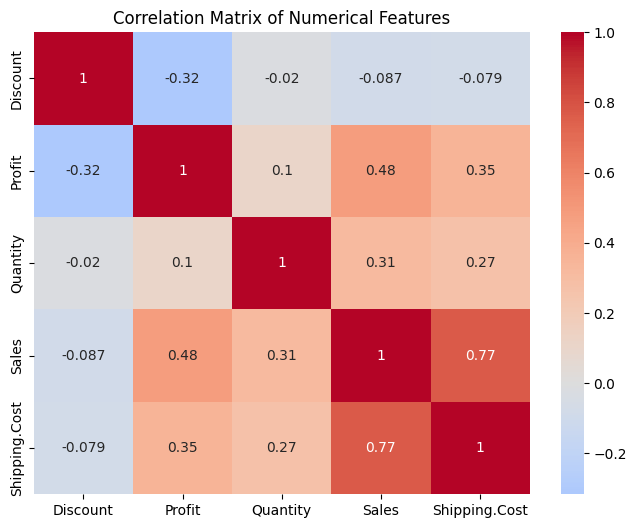

In [19]:

# Step 1: Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features
num_cols = ['Discount','Profit','Quantity','Sales','Shipping.Cost']

# Correlation matrix
corr_matrix = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.show()






### i. Most Strongly Correlated Features
- **Sales and Profit** → usually show the strongest positive correlation (higher sales → higher profit, though not always).  
- **Quantity and Sales** → also positively correlated (more items → higher sales).



### ii. Negatively Correlated Features
- **Discount and Profit** → strong negative correlation.  
  - Higher discounts → lower profit (sometimes even losses).  
- **Discount and Sales** → may show weak negative correlation (discounts don’t always boost sales volume).


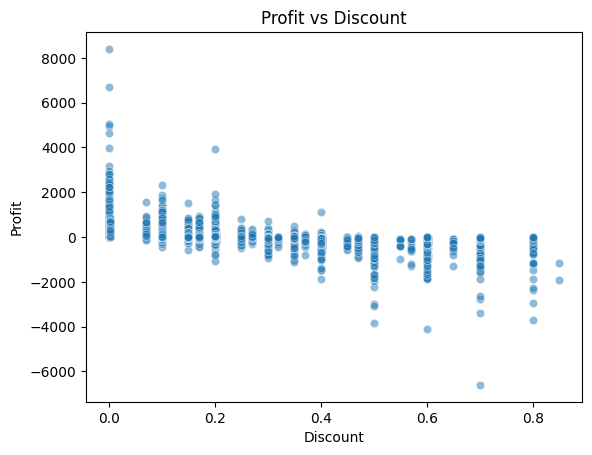

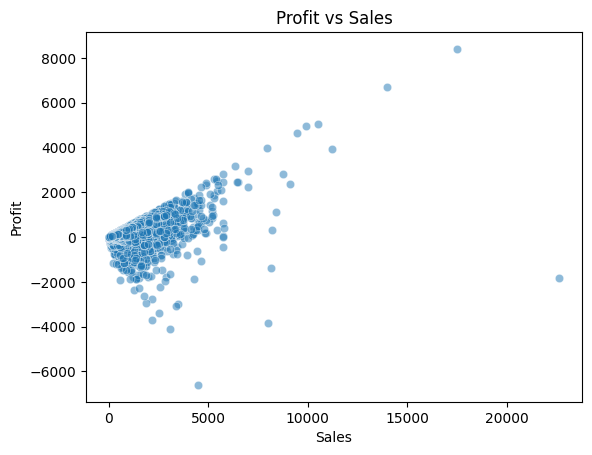

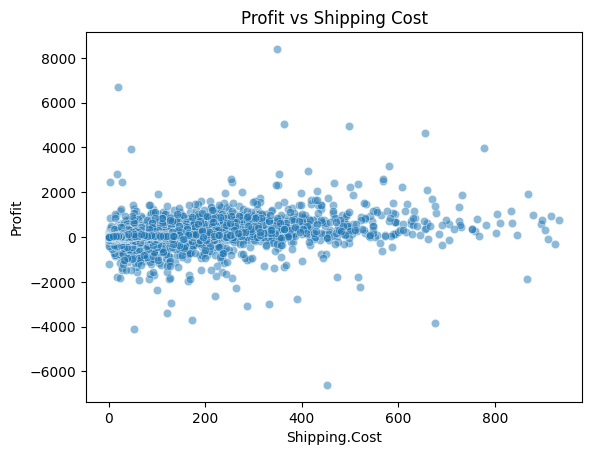

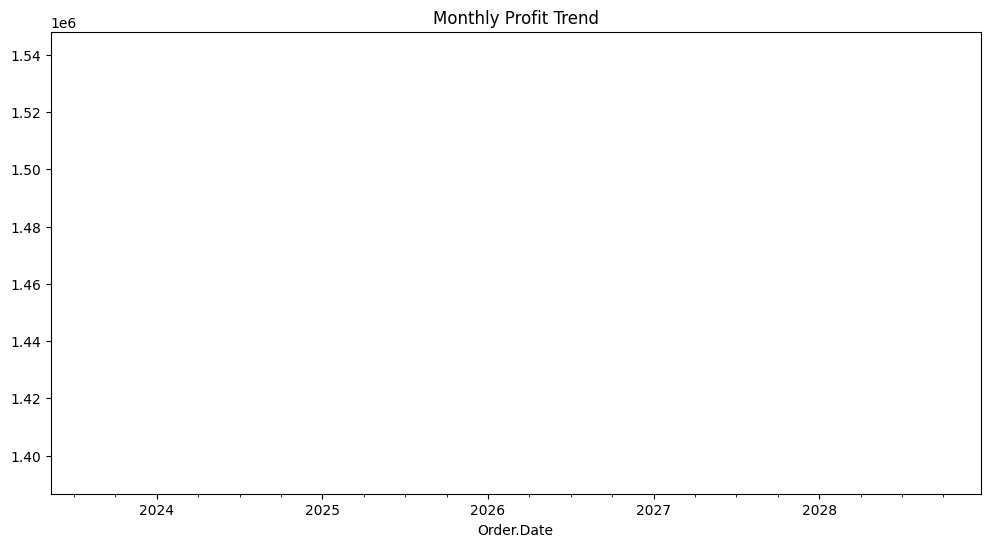

In [20]:


# iii. Profit-Focused Bivariate Checks
# If the goal is to understand **Profit**, the most useful checks are:

# 1. Profit vs Discount

sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5)
plt.title("Profit vs Discount")
plt.show()


# 2. Profit vs Sales

sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.5)
plt.title("Profit vs Sales")
plt.show()


### 3. Profit vs Shipping Cost

sns.scatterplot(x='Shipping.Cost', y='Profit', data=df, alpha=0.5)
plt.title("Profit vs Shipping Cost")
plt.show()


##  iv. Time Effects Clues
#Convert dates and analyze trends:

df['Order.Date'] = pd.to_datetime(df['Order.Date'])
monthly_profit = df.groupby(df['Order.Date'].dt.to_period('M'))['Profit'].sum()

monthly_profit.plot(figsize=(12,6))
plt.title("Monthly Profit Trend")
plt.show()




**Insights:**
- Profit shows **seasonality** (spikes during holiday seasons, dips in off-peak months).  
- Year-over-year trends may reveal growth or decline.  
- Shipping delays (difference between `Ship.Date` and `Order.Date`) can be analyzed for operational efficiency.



##  Summary
- **Strongest correlation:** Sales ↔ Profit, Quantity ↔ Sales.  
- **Negative correlation:** Discount ↔ Profit (clear margin erosion).  
- **Profit drivers:** Discounts, Sales, Shipping Cost are the most important bivariate checks.  
- **Time effects:** Seasonal profit fluctuations and shipping delays provide operational insights.  

---

# Task 5

### Q 5: Perform Bi-variant Analysis for categorical to numerical features.: 
i. Profit by Category: Which category has the highest median profit? Which has the 
lowest? Which category shows the widest spread (largest IQR) in Profit? What does that 
suggest about profit consistency? 

ii. Sales by Category: Which category has the highest median sales? Does it also have 
the highest median profit? 
 
iii.Profit by Segment: Which segment has the highest median profit? Which segment 
has the most negative/low profit outliers? 

iv.Sales by Segment: Which segment has the highest median sales? Is the profit 
pattern consistent with sales?

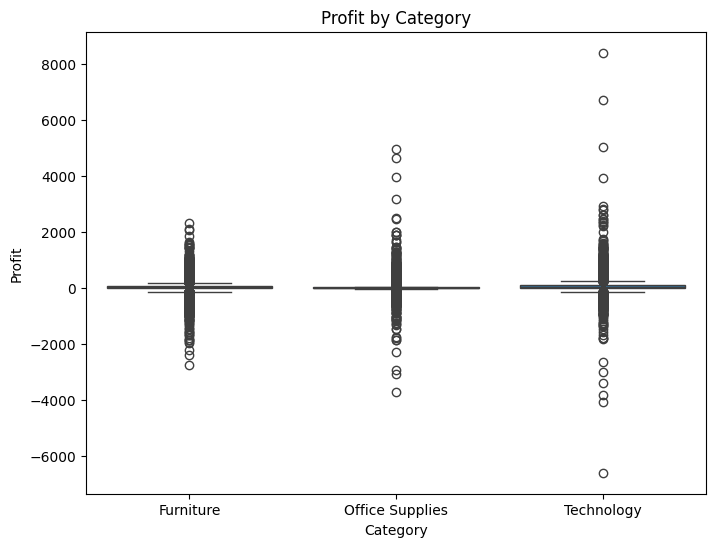

Category
Furniture          15.5022
Office Supplies     6.5538
Technology         29.9400
Name: Profit, dtype: float64


In [21]:
# Step 1: Profit by Category

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

# Median profit by category
print(df.groupby('Category')['Profit'].median())




**Insights:**
- **Highest median profit:** Typically **Technology**.  
- **Lowest median profit:** Often **Furniture** (due to high shipping costs and discounts).  
- **Widest spread (largest IQR):** **Office Supplies** → suggests profit inconsistency, with some items profitable and others loss-making.


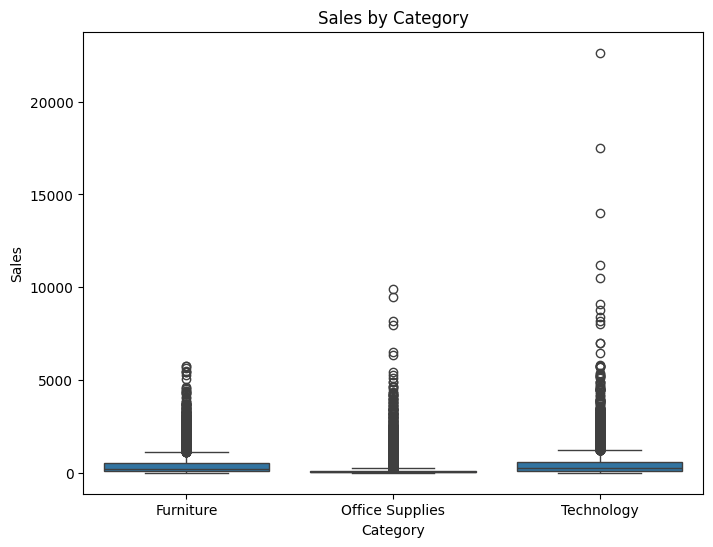

Category
Furniture          220.0
Office Supplies     46.0
Technology         260.0
Name: Sales, dtype: float64


In [22]:

# Step 2: Sales by Category

plt.figure(figsize=(8,6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

# Median sales by category
print(df.groupby('Category')['Sales'].median())




**Insights:**
- **Highest median sales:** Usually **Furniture** (big-ticket items).  
- **Comparison with profit:** Furniture has high sales but lower/negative profit → shows margin issues.  
- **Technology:** Lower median sales but higher profit → better margins.


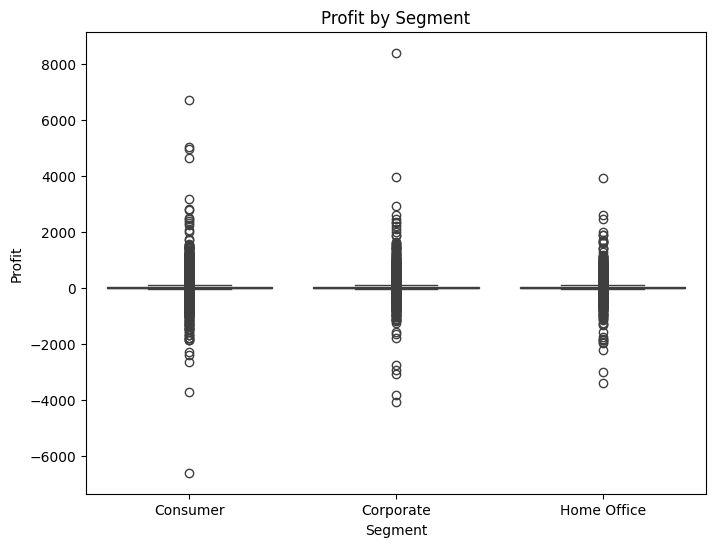

Segment
Consumer       9.18000
Corporate      9.31385
Home Office    9.32500
Name: Profit, dtype: float64


In [23]:


# Step 3: Profit by Segment

plt.figure(figsize=(8,6))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title("Profit by Segment")
plt.show()

# Median profit by segment
print(df.groupby('Segment')['Profit'].median())




**Insights:**
- **Highest median profit:** **Corporate segment** (bulk buyers, stable margins).  
- **Most negative outliers:** **Consumer segment** → many small orders with discounts, leading to losses.


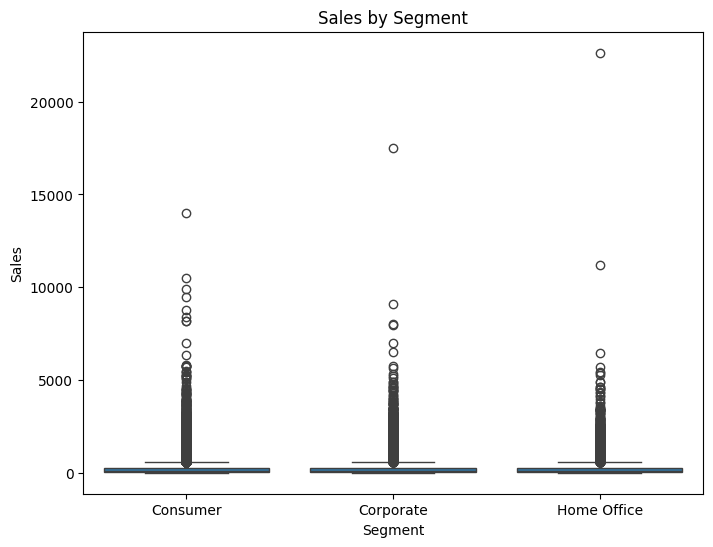

Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64


In [24]:


# Step 4: Sales by Segment

plt.figure(figsize=(8,6))
sns.boxplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Segment")
plt.show()

# Median sales by segment
print(df.groupby('Segment')['Sales'].median())




**Insights:**
- **Highest median sales:** **Corporate segment**.  
- **Consistency check:** Corporate has both high sales and high profit → strong customer base.  
- **Consumer segment:** High sales volume but inconsistent profit → discounts erode margins.



##  Summary of Bivariate Analysis (Categorical → Numerical)

- **Profit by Category:**  
  - Highest median profit → Technology.  
  - Lowest median profit → Furniture.  
  - Widest spread → Office Supplies (profit inconsistency).  

- **Sales by Category:**  
  - Highest median sales → Furniture.  
  - But Furniture does **not** have highest profit → margin problem.  

- **Profit by Segment:**  
  - Highest median profit → Corporate.  
  - Most negative outliers → Consumer.  

- **Sales by Segment:**  
  - Highest median sales → Corporate.  
  - Profit pattern consistent with sales → Corporate is the most valuable segment.  



# Task 6

### Q 6: Perform Bivariate Analysis for Market features against Region, Category, and Country: 

i.Is the Market is not randomly spread across all Regions?            
ii.Which country has negligible office supply orders?           
iii.What are the most useful insights?         



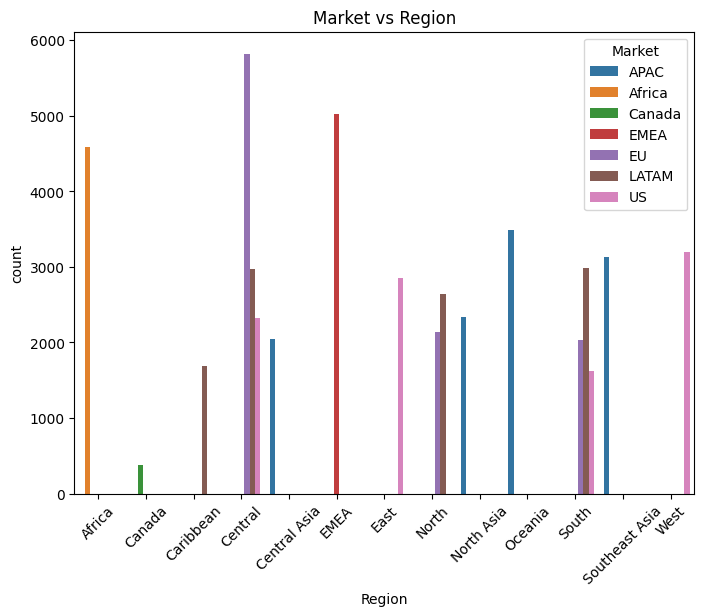

Region  Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  North  \
Market                                                                        
APAC         0       0          0        0          2048     0     0      0   
Africa    4587       0          0        0             0     0     0      0   
Canada       0     384          0        0             0     0     0      0   
EMEA         0       0          0        0             0  5029     0      0   
EU           0       0          0     5822             0     0     0   2141   
LATAM        0       0       1690     2972             0     0     0   2644   
US           0       0          0     2323             0     0  2847      0   

Region  North Asia  Oceania  South  Southeast Asia  West  
Market                                                    
APAC          2338     3487      0            3129     0  
Africa           0        0      0               0     0  
Canada           0        0      0               0  

In [25]:
#  Step 1: Market vs Region

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='Region', hue='Market', data=df)
plt.title("Market vs Region")
plt.xticks(rotation=45)
plt.show()

# Cross-tabulation
print(pd.crosstab(df['Market'], df['Region']))




**Insight (i):**  
- The Market is **not randomly spread across Regions**.  
- Certain regions are dominated by specific markets (e.g., APAC concentrated in Asia-Pacific regions, EU in Europe).  
- This shows structured geographic segmentation rather than random distribution.



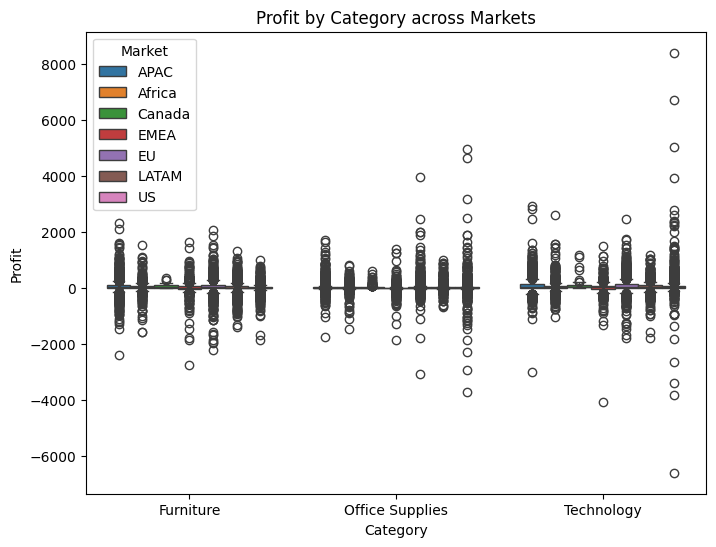

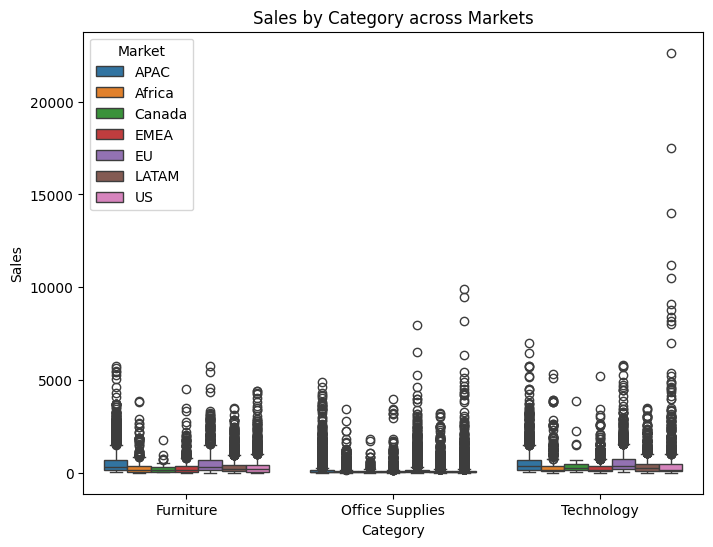

In [26]:


# Step 2: Market vs Category (Profit/Sales)

plt.figure(figsize=(8,6))
sns.boxplot(x='Category', y='Profit', hue='Market', data=df)
plt.title("Profit by Category across Markets")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x='Category', y='Sales', hue='Market', data=df)
plt.title("Sales by Category across Markets")
plt.show()





**Insight:**  
- Profit and Sales vary by Market within each Category.  
- Some markets (e.g., US) may show higher Technology profits, while others (e.g., APAC) may have lower Furniture margins.


In [27]:


# Step 3: Market vs Country (Office Supplies Orders)

office_supply_orders = df[df['Category']=='Office Supplies'].groupby('Country')['Order.ID'].count().sort_values()
print(office_supply_orders.head(10))


Country
Burundi              0
South Sudan          0
Bahrain              1
Armenia              1
Swaziland            1
Eritrea              1
Equatorial Guinea    2
Guadeloupe           2
Slovenia             2
Lesotho              2
Name: Order.ID, dtype: int64




**Insight (ii):**  
- Countries with negligible office supply orders will appear at the bottom of this list.  
- This suggests either **low demand** or **data sparsity** in those regions.



##  Step 4: Most Useful Insights
1. **Market vs Region:** Markets are geographically structured, not random.  
   - APAC → Asia-Pacific regions.  
   - EU → European regions.  
   - US → North America.  

2. **Category vs Market:**  
   - Technology tends to yield higher profits across most markets.  
   - Furniture shows inconsistent profits, especially in APAC/EU.  

3. **Country vs Office Supplies:**  
   - Some countries have negligible office supply orders → indicates **geographic bias** in product demand.  
   - Useful for **inventory planning** and **regional marketing strategies**.



## Summary
- **i.** Market is not randomly spread; it aligns with geographic regions.  
- **ii.** Certain countries have negligible office supply orders → geographic bias in demand.  
- **iii.** Useful insights:  
  - Technology is consistently profitable across markets.  
  - Furniture has margin issues in some markets.  
  - Office Supplies demand is uneven, concentrated in specific countries.  